# Exploratory Data Analysis

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Seaborn theme
sns.set_theme(style='whitegrid')

# remove non-critical warnings 
warnings.filterwarnings('ignore')

# Folder for saving figures
FIG_DIR = Path('../images')
FIG_DIR.mkdir(exist_ok=True)


def save(fig, name):
    '''
    Tighten layout, save the figure as PNG, 
    and display it.
    '''
    fig.tight_layout()
    fig.savefig(
        FIG_DIR / f'{name}.png',
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()


In [2]:
df_eda = pd.read_csv('../data/credit_default_clean.csv')
print(df_eda.shape)
df_eda.head()

(30000, 24)


,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,DEFAULT
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [3]:
df_eda.dtypes

LIMIT_BAL    int64
SEX          int64
EDUCATION    int64
MARRIAGE     int64
AGE          int64
PAY_0        int64
PAY_2        int64
PAY_3        int64
PAY_4        int64
PAY_5        int64
PAY_6        int64
BILL_AMT1    int64
BILL_AMT2    int64
BILL_AMT3    int64
BILL_AMT4    int64
BILL_AMT5    int64
BILL_AMT6    int64
PAY_AMT1     int64
PAY_AMT2     int64
PAY_AMT3     int64
PAY_AMT4     int64
PAY_AMT5     int64
PAY_AMT6     int64
DEFAULT      int64
dtype: object

In [4]:
# Check the coded demographic categories
for col in ['SEX', 'EDUCATION', 'MARRIAGE']:
    print(f'\n{col}')
    print(df_eda[col].value_counts(dropna=False).sort_index())


SEX
SEX
1    11888
2    18112
Name: count, dtype: int64

EDUCATION
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

MARRIAGE
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64


In [5]:
# Repayment-status columns
PAY_COLS = [
    'PAY_0', 'PAY_2', 'PAY_3',
    'PAY_4', 'PAY_5', 'PAY_6'
]

# Inspect repayment-status codes by month
for col in PAY_COLS:
    print(f'\n{col}')
    print(df_eda[col].value_counts(dropna=False).sort_index())


PAY_0
PAY_0
-2     2759
-1     5686
 0    14737
 1     3688
 2     2667
 3      322
 4       76
 5       26
 6       11
 7        9
 8       19
Name: count, dtype: int64

PAY_2
PAY_2
-2     3782
-1     6050
 0    15730
 1       28
 2     3927
 3      326
 4       99
 5       25
 6       12
 7       20
 8        1
Name: count, dtype: int64

PAY_3
PAY_3
-2     4085
-1     5938
 0    15764
 1        4
 2     3819
 3      240
 4       76
 5       21
 6       23
 7       27
 8        3
Name: count, dtype: int64

PAY_4
PAY_4
-2     4348
-1     5687
 0    16455
 1        2
 2     3159
 3      180
 4       69
 5       35
 6        5
 7       58
 8        2
Name: count, dtype: int64

PAY_5
PAY_5
-2     4546
-1     5539
 0    16947
 2     2626
 3      178
 4       84
 5       17
 6        4
 7       58
 8        1
Name: count, dtype: int64

PAY_6
PAY_6
-2     4895
-1     5740
 0    16286
 2     2766
 3      184
 4       49
 5       13
 6       19
 7       46
 8        2
Name: count, dtype: int6

In [6]:
# check negative bill amounts
BILL_COLS = [f'BILL_AMT{i}' for i in range(1, 7)]

# Count negative bill amounts in each month
(df_eda[BILL_COLS] < 0).sum()

BILL_AMT1    590
BILL_AMT2    669
BILL_AMT3    655
BILL_AMT4    675
BILL_AMT5    655
BILL_AMT6    688
dtype: int64

**Note:** The negative bill balances in the dataset are retained because they may represent customer credits or overpayments rather than data errors.

## EDA Preparation

In [7]:
# variable groups used throughout the EDA
MONTHS = ['Sep', 'Aug', 'Jul', 'Jun', 'May', 'Apr']

BILL_COLS = [f'BILL_AMT{i}' for i in range(1, 7)]

PAYAMT_COLS = [f'PAY_AMT{i}' for i in range(1, 7)]

CAT_COLS = ['SEX', 'EDUCATION', 'MARRIAGE']

TARGET = 'DEFAULT'

In [8]:
# readable labels for categorical variables
LABELS = {
    'SEX': {
        1: 'Male',
        2: 'Female'
    },
    'EDUCATION': {
        1: 'Graduate school',
        2: 'University',
        3: 'High school',
        4: 'Other'
    },
    'MARRIAGE': {
        1: 'Married',
        2: 'Single',
        3: 'Other'
    }
}

# Create readable categorical columns for visualization
for col, mapping in LABELS.items():
    df_eda[f'{col}_label'] = pd.Categorical(
        df_eda[col].map(mapping),
        categories=list(mapping.values()),
        ordered=(col == 'EDUCATION')
    )

# Readable target variable
df_eda['DEFAULT_label'] = pd.Categorical(
    df_eda[TARGET].map({
        0: 'No default',
        1: 'Default'
    }),
    categories=['No default', 'Default']
)

In [9]:
# group age into interpretable ranges for comparison
df_eda['AGE_GROUP'] = pd.cut(
    df_eda['AGE'],
    bins=[20, 29, 39, 49, 59, 69, 100],
    labels=['20-29', '30-39', '40-49', '50-59', '60-69', '70+'],
    include_lowest=True
)

In [10]:
# The UCI documentation defines -1 as paid duly and positive values as increasing months of payment delay.
PAY_LABELS = {
    -2: 'Unknown (-2)',
    -1: 'Paid on Time',
    0: 'Unknown (0)',
    1: '1 Month Delay',
    2: '2 Months Delay',
    3: '3 Months Delay',
    4: '4 Months Delay',
    5: '5 Months Delay',
    6: '6 Months Delay',
    7: '7 Months Delay',
    8: '8 Months Delay',
    9: '9+ Months Delay'
}

# Chronological order for plots
MONTH_ORDER = MONTHS[::-1]

# Convert repayment history from wide to long format
pay_long = df_eda.melt(
    id_vars=TARGET,
    value_vars=PAY_COLS,
    var_name='month',
    value_name='status'
)

pay_long['month'] = pd.Categorical(
    pay_long['month'].map(dict(zip(PAY_COLS, MONTHS))),
    categories=MONTH_ORDER,
    ordered=True
)

present_statuses = [
    PAY_LABELS[k]
    for k in sorted(pay_long['status'].unique())
]

pay_long['status_label'] = pd.Categorical(
    pay_long['status'].map(PAY_LABELS),
    categories=present_statuses,
    ordered=True
)

pay_long.head()


,DEFAULT,month,status,status_label
0,1,Sep,2,2 Months Delay
1,1,Sep,-1,Paid on Time
2,0,Sep,0,Unknown (0)
3,0,Sep,0,Unknown (0)
4,0,Sep,-1,Paid on Time


**Note:** The UCI documentation defines repayment status as `-1` for on-time payments (Paid Duly) and 1-9 for increasing months of payment delay. Exploratory analysis identified additional values of `-2` and `0` in the dataset that the repository's description does not define. During exploratory analysis, these categories were retained as separate unknown categories rather than assigning them interpretations not supported by the provided documentation. However, these values seem to indicate non-delinquency, based on their frequency and placement relative to `-1` (Paid Duly) and to positive delinquency codes, rather than reflecting increasing payment delays.

## Target Variable

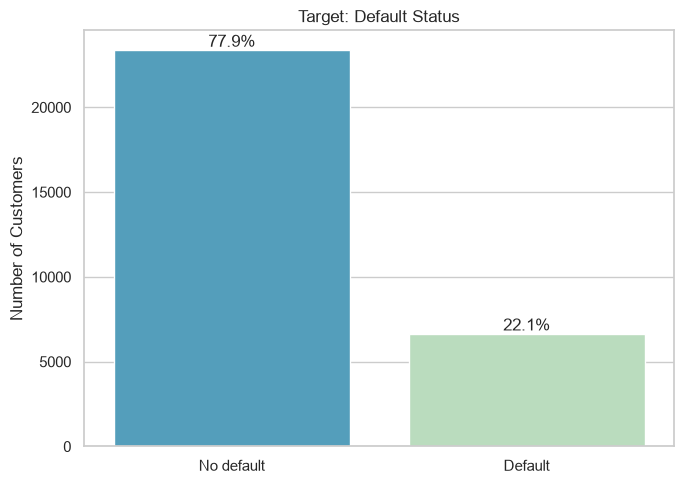

,DEFAULT_label,proportion
0,No default,0.779
1,Default,0.221


In [11]:
# Distribution of the target variable
fig, ax = plt.subplots(figsize=(7, 5))

sns.countplot(
    data=df_eda,
    x='DEFAULT_label',
    palette='GnBu_r',
    legend=False,
    ax=ax
)

# Add percentage labels above the bars
for bar in ax.patches:
    percentage = bar.get_height() / len(df_eda)

    ax.annotate(
        f'{percentage:.1%}',
        (
            bar.get_x() + bar.get_width() / 2,
            bar.get_height()
        ),
        ha='center',
        va='bottom'
    )

ax.set(
    title='Target: Default Status',
    xlabel='',
    ylabel='Number of Customers'
)

plt.tight_layout()
plt.show()

save(fig, 'target_default')

# Target proportions
df_eda['DEFAULT_label'].value_counts(normalize=True).round(3).reset_index() 

**Finding:** Approximately 22.1% of customers defaulted in the following month, while 77.9% did not. The target is therefore imbalanced, which should be considered when evaluating the predictive models.

### Demographic Characteristics and Default

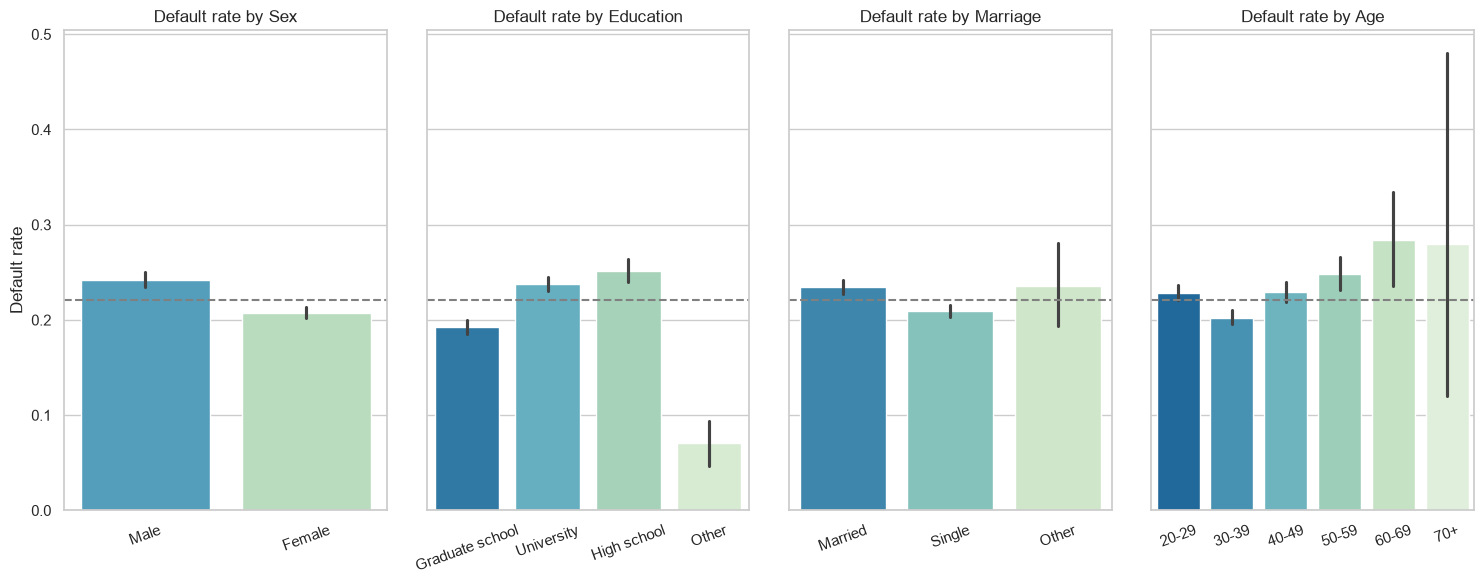

In [12]:
# overall default rate used as a reference line
overall_rate = df_eda[TARGET].mean()

fig, axes = plt.subplots(1, 4,figsize=(15,6), sharey=True)

# sex, education, and marriage
for ax, col in zip(axes[:3], CAT_COLS):
    sns.barplot(
        data=df_eda,
        x=f'{col}_label',
        y=TARGET,
        palette='GnBu_r',
        ax=ax
    )

    ax.axhline(
        overall_rate,
        linestyle='--',
        color='grey'
    )

    ax.set(
        title=f'Default rate by {col.title()}',
        xlabel='',
        ylabel='Default rate'
    )

    ax.tick_params(
        axis='x',
        rotation=20
    )

# age
sns.barplot(
    data=df_eda,
    x='AGE_GROUP',
    y=TARGET,
    palette='GnBu_r',
    ax=axes[3]
)

axes[3].axhline(
    overall_rate,
    linestyle='--',
    color='grey'
)

axes[3].set(
    title='Default rate by Age',
    xlabel='',
    ylabel='Default rate'
)

axes[3].tick_params(
    axis='x',
    rotation=20
)

plt.tight_layout()
plt.show()

save(fig, 'demographics_default')

**Findings:** Default rates vary across demographic segments. Male customers demonstrate a moderately higher propensity to default compared to female customers. Customers with university and high-school education levels show higher default rates than those with graduate education. Marital status differences are minimal; Married and "Other" customers are slightly above the overall rate. Default rates by age are lowest among the 30-39 age group and tend to increase with age; however, wider confidence intervals for customers aged 60 and above suggest that estimates are less precise. 

## Financial and Repayment Behavior

### Bill Amounts

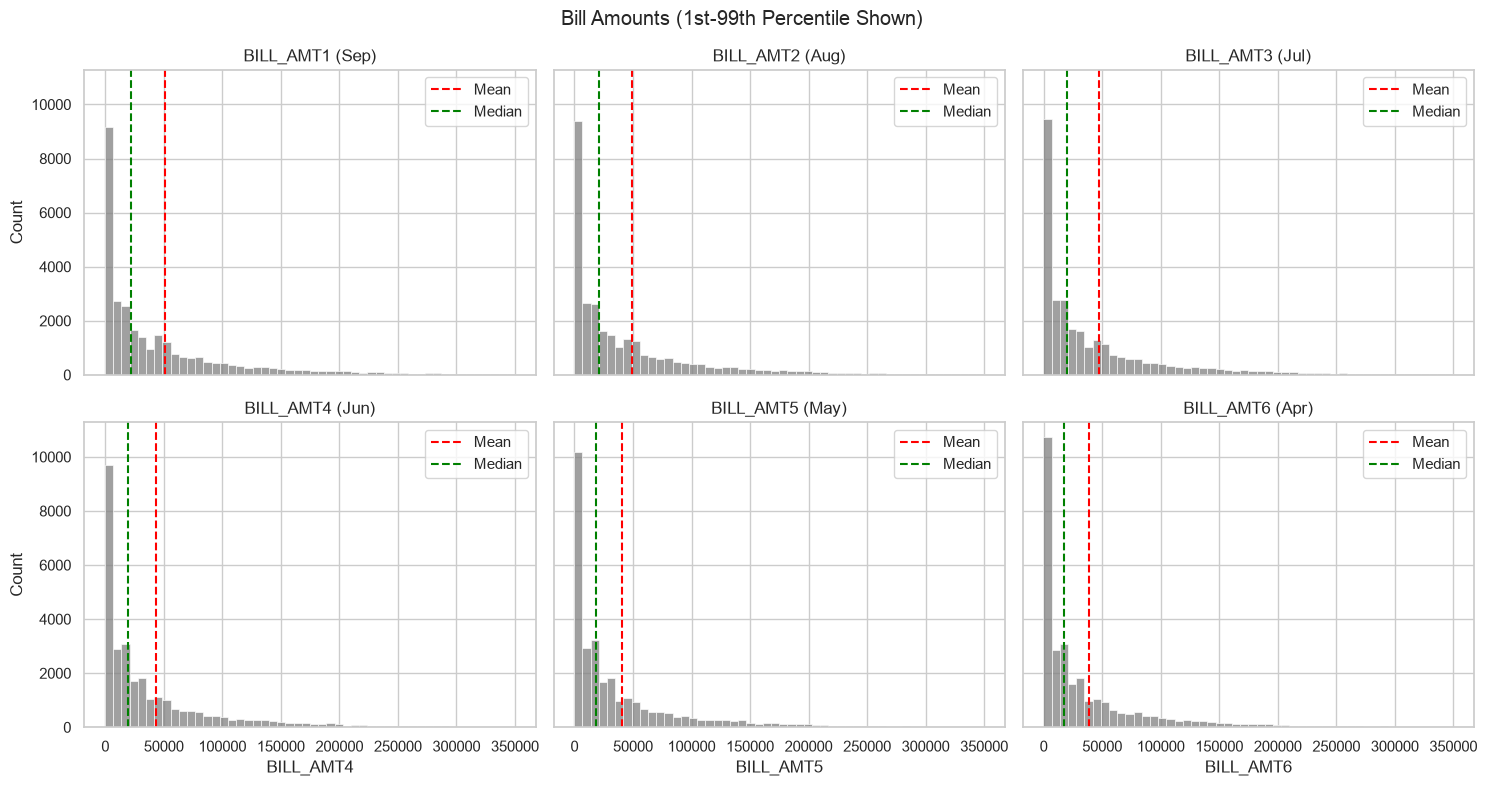

,count,mean,std,min,25%,50%,75%,max,skew,negatives
BILL_AMT1,30000.0,51223.3,73635.9,-165580.0,3558.8,22381.5,67091.0,964511.0,2.7,590
BILL_AMT2,30000.0,49179.1,71173.8,-69777.0,2984.8,21200.0,64006.2,983931.0,2.7,669
BILL_AMT3,30000.0,47013.2,69349.4,-157264.0,2666.2,20088.5,60164.8,1664089.0,3.1,655
BILL_AMT4,30000.0,43262.9,64332.9,-170000.0,2326.8,19052.0,54506.0,891586.0,2.8,675
BILL_AMT5,30000.0,40311.4,60797.2,-81334.0,1763.0,18104.5,50190.5,927171.0,2.9,655
BILL_AMT6,30000.0,38871.8,59554.1,-339603.0,1256.0,17071.0,49198.2,961664.0,2.8,688


In [13]:
# central 98% of bill amounts so extreme observations do not compress distributions.
low = df_eda[BILL_COLS].quantile(0.01).min()
high = df_eda[BILL_COLS].quantile(0.99).max()

fig, axes = plt.subplots(2,3, figsize=(15, 8), sharex=True, sharey=True)

for ax, col, month in zip(axes.flat, BILL_COLS, MONTHS):
    sns.histplot(
        data=df_eda,
        x=col,
        bins=50,
        binrange=(low, high),
        color='grey',
        ax=ax
    )

    ax.axvline(
        df_eda[col].mean(),
        color='red',
        linestyle='--',
        label='Mean'
    )

    ax.axvline(
        df_eda[col].median(),
        color='green',
        linestyle='--',
        label='Median'
    )

    ax.legend()
    ax.set_title(f'{col} ({month})')

fig.suptitle('Bill Amounts (1st-99th Percentile Shown)')
plt.tight_layout()
plt.show()

# Summary statistics for monthly bill amounts
bill_stats = df_eda[BILL_COLS].describe().T
bill_stats['skew'] = df_eda[BILL_COLS].skew()
bill_stats['negatives'] = (df_eda[BILL_COLS] < 0).sum()

bill_stats.round(1)

**Findings:** The six-month bill amount variables show similar, strongly right-skewed distributions, with most customers having relatively low outstanding balances and only a few carrying larger balances. In every month, the mean exceeds the median, indicating that high-balance observations pull the average upward. Both the mean and median bill amounts generally increase from April to September, suggesting higher billed balances in more recent months. Negative balances are also present across all six months and may represent customer credits or overpayments rather than data errors.

### Payment Amounts

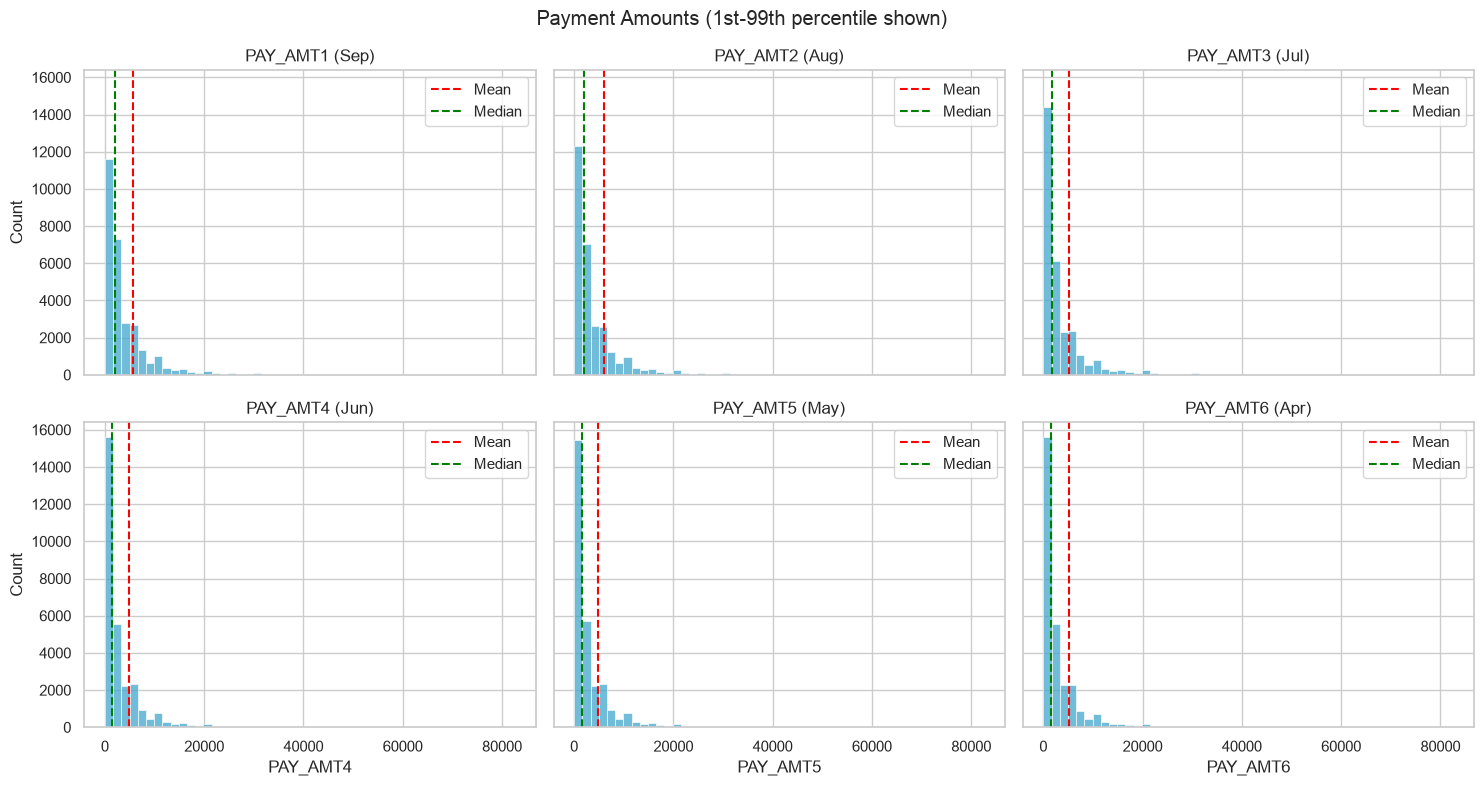

,count,mean,std,min,25%,50%,75%,max,skew,zero_payments
PAY_AMT1,30000.0,5663.6,16563.3,0.0,1000.0,2100.0,5006.0,873552.0,14.7,5249
PAY_AMT2,30000.0,5921.2,23040.9,0.0,833.0,2009.0,5000.0,1684259.0,30.5,5396
PAY_AMT3,30000.0,5225.7,17607.0,0.0,390.0,1800.0,4505.0,896040.0,17.2,5968
PAY_AMT4,30000.0,4826.1,15666.2,0.0,296.0,1500.0,4013.2,621000.0,12.9,6408
PAY_AMT5,30000.0,4799.4,15278.3,0.0,252.5,1500.0,4031.5,426529.0,11.1,6703
PAY_AMT6,30000.0,5215.5,17777.5,0.0,117.8,1500.0,4000.0,528666.0,10.6,7173


In [14]:
# visualize visible data, view of the 1st to 99th percentile
low = df_eda[PAYAMT_COLS].quantile(0.01).min()
high = df_eda[PAYAMT_COLS].quantile(0.99).max()

# sharex/sharey put every panel on the same scale
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)

color = sns.color_palette('GnBu_r', 2)[0]

# axes.flat walks through the 6 panels in order, one per month
for ax, col, month in zip(axes.flat, PAYAMT_COLS, MONTHS):
    sns.histplot(
        data=df_eda, 
        x=col, 
        bins=50,  
        binrange=(low, high),
        color=color,
        ax=ax
)
    ax.axvline(
        df_eda[col].mean(),
        color = 'red', 
        linestyle = '--'
    )
    
    ax.axvline(
        df_eda[col].median(), 
        color='green', 
        linestyle = '--')
    
    ax.legend(['Mean', 'Median'])
    ax.set_title(f"{col} ({month})")

fig.suptitle("Payment Amounts (1st-99th percentile shown)")
plt.tight_layout()
plt.show()

# Summary table, one row per month
payment_stats = df_eda[PAYAMT_COLS].describe().T
payment_stats["skew"] = df_eda[PAYAMT_COLS].skew()
payment_stats["zero_payments"] = (df_eda[PAYAMT_COLS] == 0).sum()
payment_stats.round(1)

**Findings:** Payment amounts are highly right-skewed across all six months, with most customers making relatively small payments. Mean payments consistently exceed median payments, reflecting the influence of extreme high-value transactions. 

### Repayment Status

In [15]:
# Count repayment status observations within each month
status_month_counts = (
    pay_long
    .groupby(
        ['month', 'status_label'],
        observed=True
    )
    .size()
    .reset_index(name='count')
)

status_month_counts.head()

,month,status_label,count
0,Apr,Unknown (-2),4895
1,Apr,Paid on Time,5740
2,Apr,Unknown (0),16286
3,Apr,2 Months Delay,2766
4,Apr,3 Months Delay,184


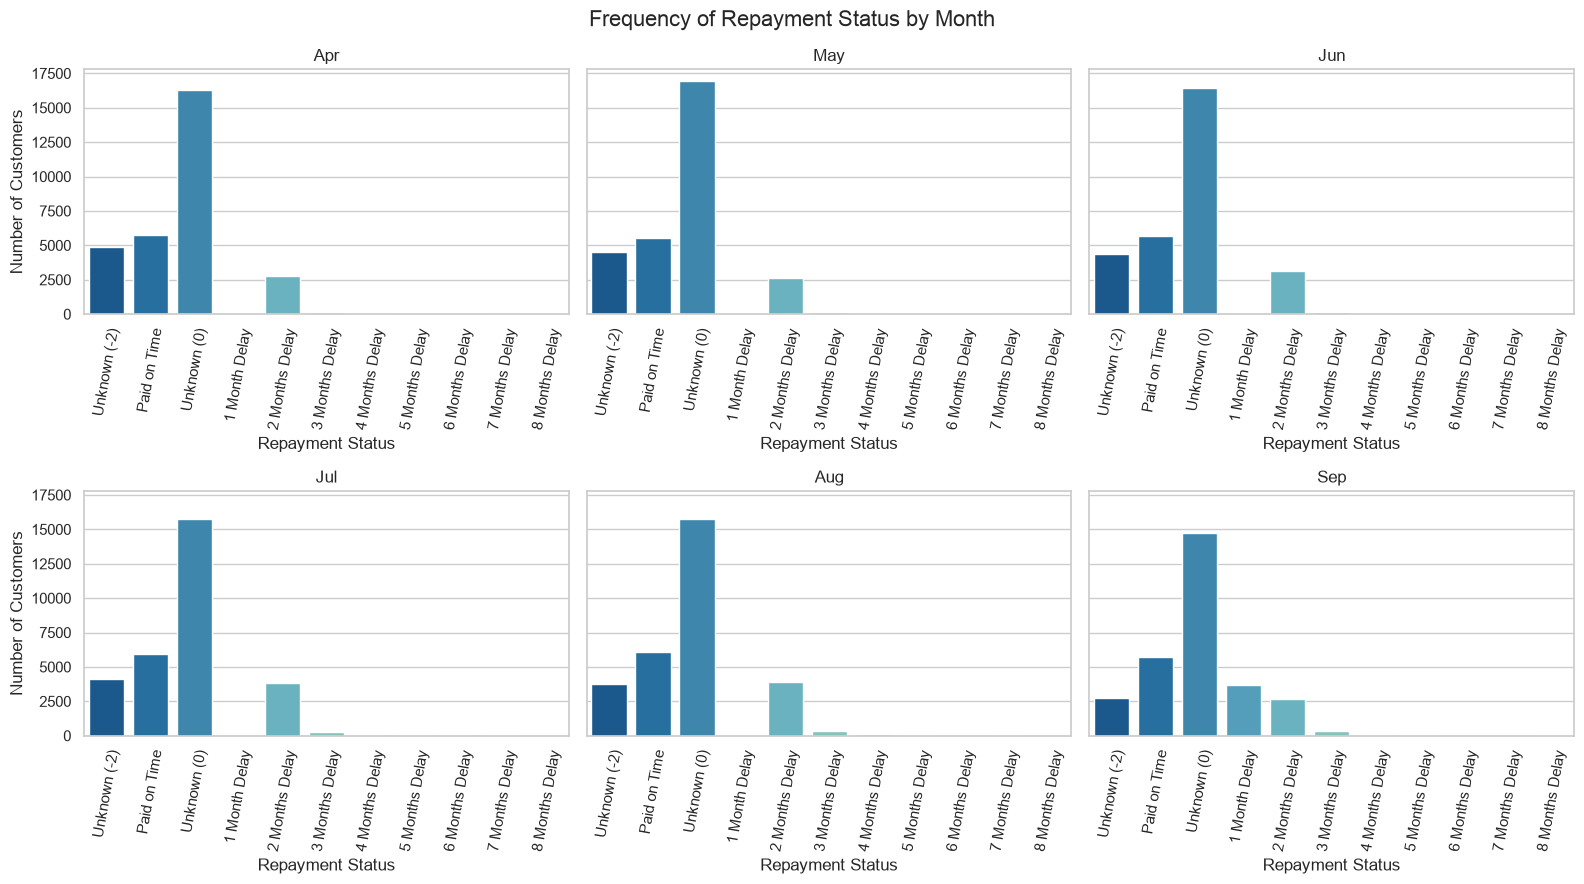

In [16]:
fig, axes = plt.subplots(2, 3,figsize=(16, 9),sharey=True)

axes = axes.flatten()

for ax, month in zip(axes, MONTH_ORDER):

    # Select observations for the current month
    month_data = status_month_counts[
        status_month_counts['month'] == month
    ]

    # Plot frequency of each repayment status
    sns.barplot(
        data=month_data,
        x='status_label',
        y='count',
        palette='GnBu_r',
        ax=ax
    )

    ax.set_title(month)
    ax.set_xlabel('Repayment Status')
    ax.set_ylabel('Number of Customers')

    ax.tick_params(
        axis='x',
        rotation=80
    )

fig.suptitle(
    'Frequency of Repayment Status by Month',
    fontsize=16
)

plt.tight_layout()
plt.show()

**Findings:** Repayment status frequencies are highly uneven across the six months. The `Unknown (0)` status is the most common category throughout the period, followed by `Paid on Time`, `Unknown (-2)`, and `2 Months Delay`. Because the severe-delay categories have relatively few observations, their association with default rates may be less reliable. 

In [17]:
# Count customers in each repayment status for each month
status_pct = (
    pay_long
    .groupby(
        ['month', 'status_label'],
        observed=True
    )
    .size()
    .reset_index(name='count')
)

# Calculate percentage within each month
status_pct['percentage'] = (
    status_pct['count']
    / status_pct.groupby('month')['count'].transform('sum')
    * 100
)

status_pct.head()

,month,status_label,count,percentage
0,Apr,Unknown (-2),4895,16.316667
1,Apr,Paid on Time,5740,19.133333
2,Apr,Unknown (0),16286,54.286667
3,Apr,2 Months Delay,2766,9.220000
4,Apr,3 Months Delay,184,0.613333


### Median Payment Amount by Repayment Status

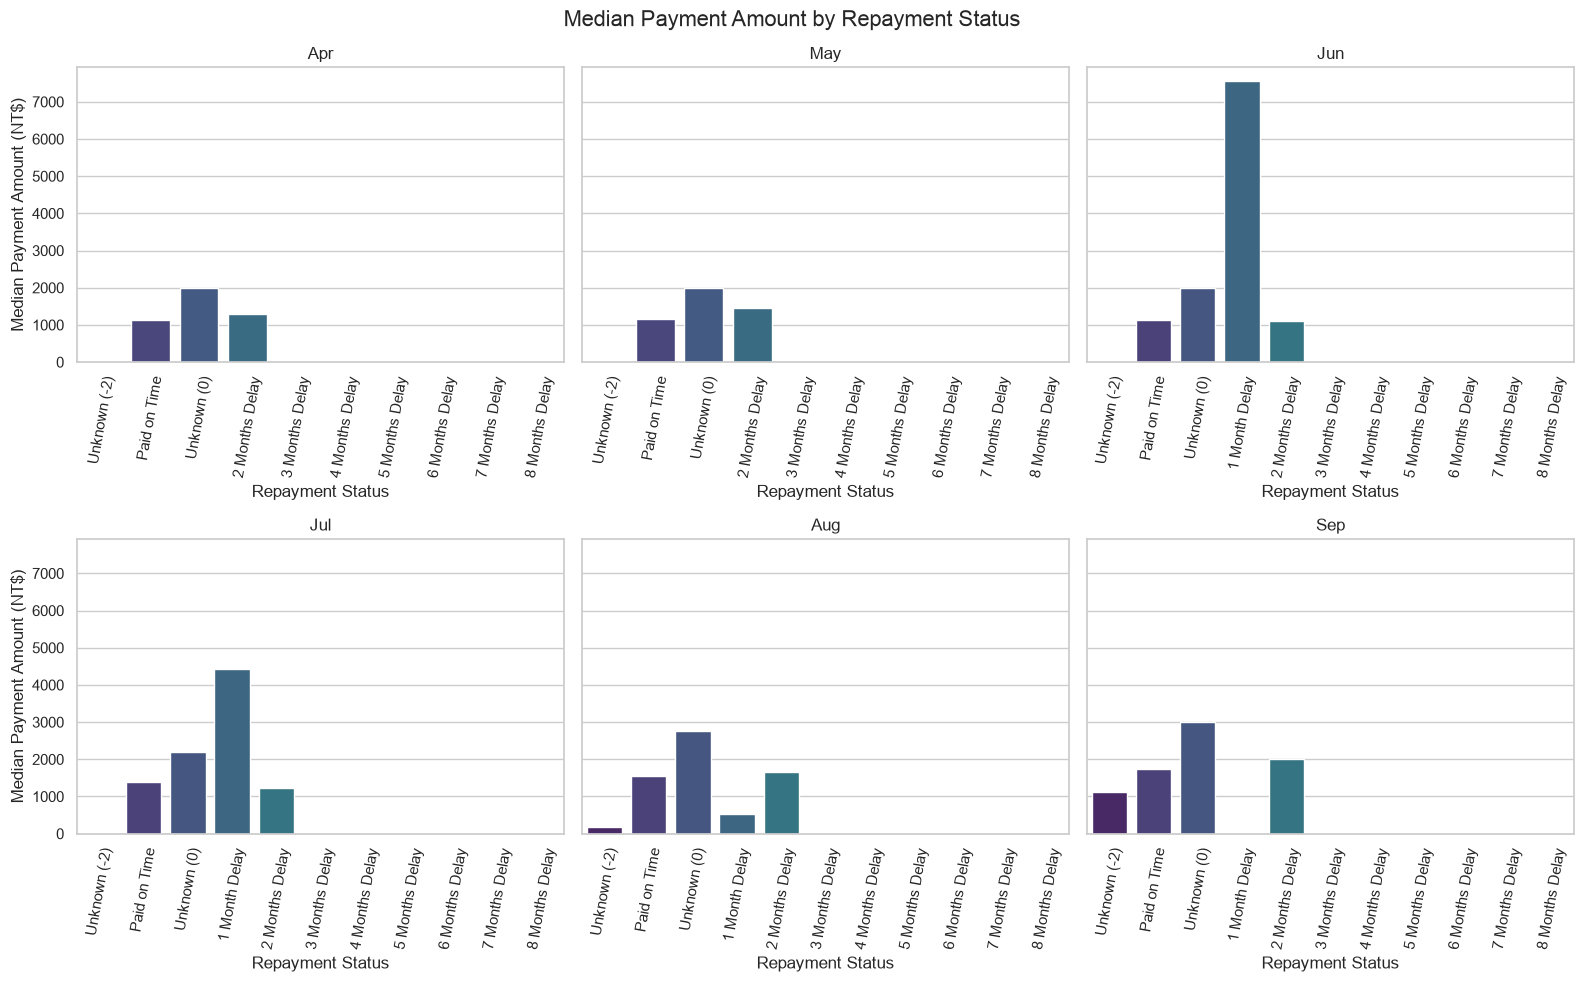

In [18]:
# repayment status with payment amount for each month
month_pairs = [
    ('PAY_6', 'PAY_AMT6', 'Apr'),
    ('PAY_5', 'PAY_AMT5', 'May'),
    ('PAY_4', 'PAY_AMT4', 'Jun'),
    ('PAY_3', 'PAY_AMT3', 'Jul'),
    ('PAY_2', 'PAY_AMT2', 'Aug'),
    ('PAY_0', 'PAY_AMT1', 'Sep')
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10), sharey=True)

axes = axes.flatten()

for ax, (status_col, payment_col, month) in zip(
    axes,
    month_pairs
):
    # Calculate median payment for each repayment status
    payment_by_status = (
        df_eda
        .groupby(status_col, observed=True)[payment_col]
        .median()
        .reset_index()
    )

    # Convert numerical status to descriptive labels
    payment_by_status['status_label'] = (
        payment_by_status[status_col].map(PAY_LABELS)
    )

    # Create bar chart
    sns.barplot(
        data=payment_by_status,
        x='status_label',
        y=payment_col,
        palette='viridis',
        ax=ax
    )

    ax.set_title(month)
    ax.set_xlabel('Repayment Status')
    ax.set_ylabel('Median Payment Amount (NT$)')

    # Rotate labels so they are readable
    ax.tick_params(
        axis='x',
        rotation=80
    )

fig.suptitle(
    'Median Payment Amount by Repayment Status',
    fontsize=16
)
plt.tight_layout()
plt.show()
save(fig, 'Median_Payment_Amount_by_Repayment_Status')

**Findings:** Over the six-month period, median payment amounts vary considerably across repayment-status categories. Customers with the `unknown (0)` status generally have higher median payments than those classified as `Paid on Time` or those with documented payment delays. However, increasingly severe delays do not consistently correspond to lower payment amounts. Overall, the results suggest that repayment status cannot be explained by payment amount alone and should be considered alongside bill amounts and other repayment behavior.

### Median Bill Amount by Repayment Status

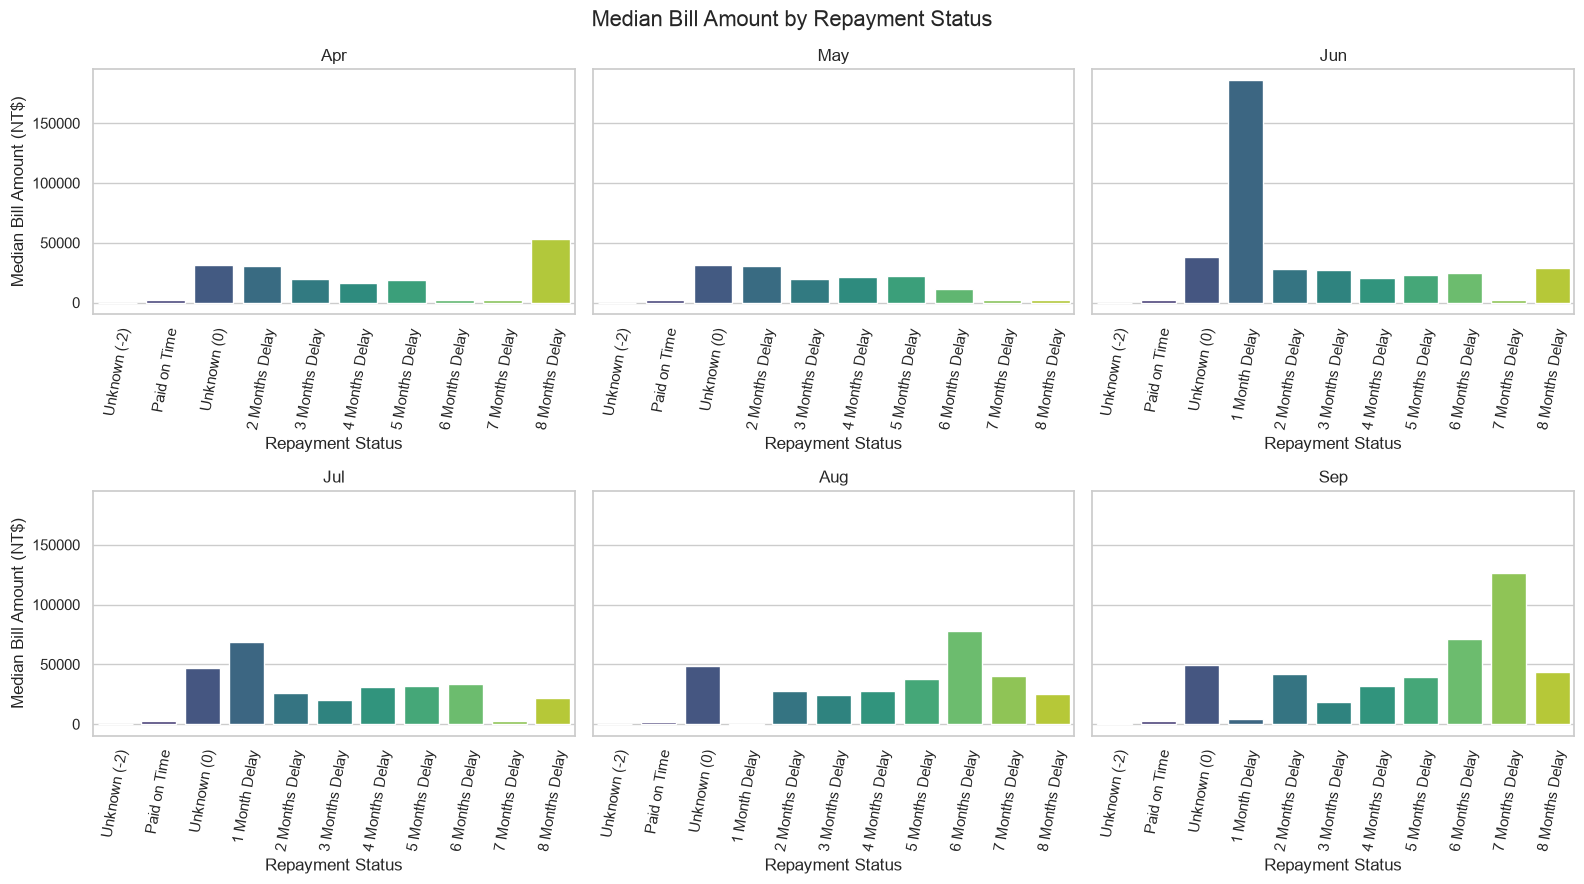

In [19]:
# Match repayment status with bill amount for each month
bill_month_pairs = [
    ('PAY_6', 'BILL_AMT6', 'Apr'),
    ('PAY_5', 'BILL_AMT5', 'May'),
    ('PAY_4', 'BILL_AMT4', 'Jun'),
    ('PAY_3', 'BILL_AMT3', 'Jul'),
    ('PAY_2', 'BILL_AMT2', 'Aug'),
    ('PAY_0', 'BILL_AMT1', 'Sep')
]


fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)

axes = axes.flatten()

for ax, (status_col, bill_col, month) in zip(
    axes,
    bill_month_pairs
):
    # Calculate median bill amount for each repayment status
    bill_by_status = (
        df_eda
        .groupby(status_col, observed=True)[bill_col]
        .median()
        .reset_index()
    )

    # Convert numerical repayment status to descriptive labels
    bill_by_status['status_label'] = (
        bill_by_status[status_col].map(PAY_LABELS)
    )

    # Create bar chart
    sns.barplot(
        data=bill_by_status,
        x='status_label',
        y=bill_col,
        palette='viridis',
        ax=ax
    )

    ax.set_title(month)
    ax.set_xlabel('Repayment Status')
    ax.set_ylabel('Median Bill Amount (NT$)')

    # Rotate labels for readability
    ax.tick_params(
        axis='x',
        rotation=80
    )

fig.suptitle(
    'Median Bill Amount by Repayment Status',
    fontsize=16
)

plt.tight_layout()
plt.show()
save(fig, 'Median_Bill_Amount_by_Repayment_Status')

**Findings:** Median bill amounts vary considerably across repayment-status categories and over the six-month period. Customers classified as `Paid on Time` generally have low median bill balances, while those with `Unknown (0)` status and those with payment delays tend to carry higher balances. Interpretations should take into account that earlier frequency analysis showed that severe-delay categories contain relatively few observations. 
 

### Default Rate by Repayment Status

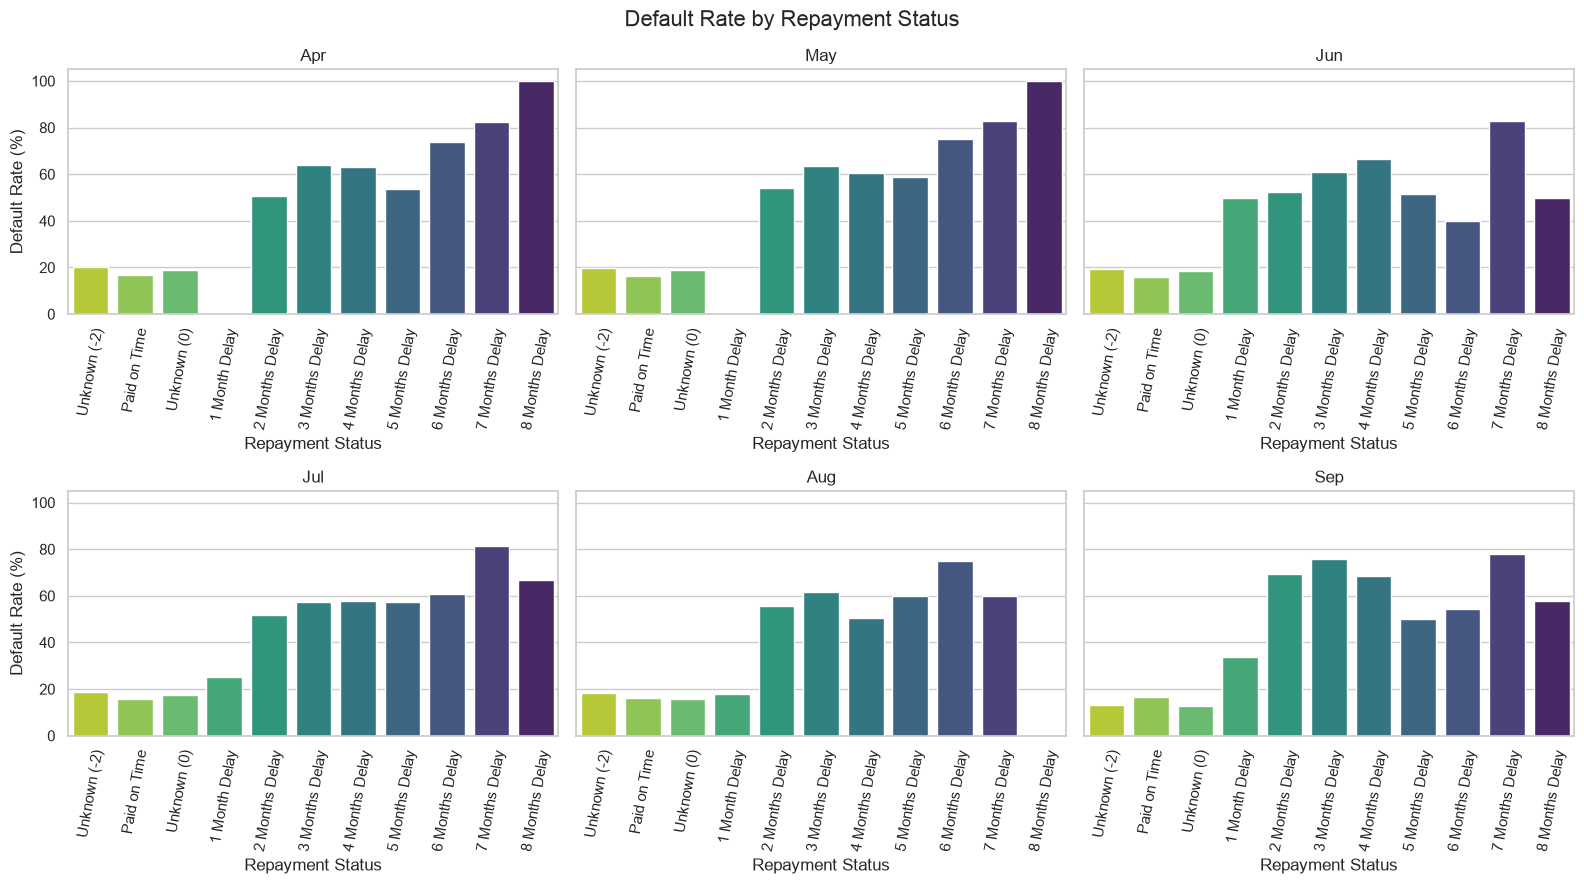

In [20]:
#  default rate within each month and repayment status
default_by_status = (
    pay_long.groupby(['month', 'status_label'], observed=True)[TARGET].agg(default_rate='mean', customer_count='count').reset_index()
)

# Convert default rate to percentage
default_by_status['default_rate'] *= 100


fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)

axes = axes.flatten()

for ax, month in zip(axes, MONTH_ORDER):

    
    month_data = default_by_status[default_by_status['month'] == month]

    # Plot default rate by repayment status
    sns.barplot(
        data=month_data,
        x='status_label',
        y='default_rate',
        palette='viridis_r',   
        ax=ax
    )

    ax.set_title(month)
    ax.set_xlabel('Repayment Status')
    ax.set_ylabel('Default Rate (%)')

    ax.tick_params(
        axis='x',
        rotation=80
    )

fig.suptitle(
    'Default Rate by Repayment Status',
    fontsize=16
)

plt.tight_layout()
plt.show()
save(fig, 'Default_Rate_by_Repayment_Status')

**Findings:** Repayment status shows a strong relationship with default across the six-month period. Customers classified as `Paid on Time` and those in the Unknown `-2` and `0` categories generally show default rates below 20%, compared with those with payment delays. Default rates increase significantly as customers become delinquent, and those with delays of two months or more often have default rates exceeding 50%. **This suggests that recent payment delays and their severity could help identify higher-risk customers.**

### Credit Utilization Analysis

In [21]:
# Calculate monthly credit utilization
for i in range(1, 7):
    df_eda[f'UTIL_{i}'] = (df_eda[f'BILL_AMT{i}']/ df_eda['LIMIT_BAL'])

util_cols = [
    'UTIL_1',
    'UTIL_2',
    'UTIL_3',
    'UTIL_4',
    'UTIL_5',
    'UTIL_6'
]

# df_eda[util_cols].describe()
df_eda[util_cols].agg(['min', 'median', 'mean', 'max']).T

,min,median,mean,max
UTIL_1,-0.619892,0.313994,0.423771,6.455300
UTIL_2,-1.395540,0.296057,0.411128,6.380500
UTIL_3,-1.025100,0.273135,0.392192,10.688575
UTIL_4,-1.374500,0.242066,0.359503,5.146850
UTIL_5,-0.876743,0.212026,0.333108,4.935500
UTIL_6,-1.509530,0.185224,0.318585,3.885550


#### Create utilization bands

In [22]:
# credit utilization bands
util_bins = [
    -float('inf'),
    0,
    0.25,
    0.50,
    0.75,
    1.00,
    float('inf')
]

util_labels = [
    '<= 0%',
    '0-25%',
    '25-50%',
    '50-75%',
    '75-100%',
    '> 100%'
]

In [23]:
# convert utilization variables from wide to long format
util_long = df_eda.melt(
    id_vars=TARGET,
    value_vars=util_cols,
    var_name='util_month',
    value_name='utilization'
)

# match utilization variables to months
util_month_map = {
    'UTIL_6': 'Apr',
    'UTIL_5': 'May',
    'UTIL_4': 'Jun',
    'UTIL_3': 'Jul',
    'UTIL_2': 'Aug',
    'UTIL_1': 'Sep'
}

util_long['month'] = (
    util_long['util_month']
    .map(util_month_map)
)

# keep months in chronological order
util_long['month'] = pd.Categorical(
    util_long['month'],
    categories=['Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep'],
    ordered=True
)

In [24]:
# assing each observation to a utilization band
util_long['util_band'] = pd.cut(util_long['utilization'], bins=util_bins, labels=util_labels)

util_long.head()

,DEFAULT,util_month,utilization,month,util_band
0,1,UTIL_1,0.195650,Sep,0-25%
1,1,UTIL_1,0.022350,Sep,0-25%
2,0,UTIL_1,0.324878,Sep,25-50%
3,0,UTIL_1,0.939800,Sep,75-100%
4,0,UTIL_1,0.172340,Sep,0-25%


In [25]:
# assing each observation to a utilization band
util_long['util_band'] = pd.cut(util_long['utilization'], bins=util_bins, labels=util_labels)

# count customers in each utilization band by month
util_distribution = util_long.groupby(['month', 'util_band'], observed=True).size().reset_index(name='count')

# percentage within each month
# utilization bands are interpreted as the proportion of customers falling within each level.
util_distribution['percentage'] = (
    util_distribution['count'] / util_distribution.groupby('month')['count'].transform('sum') * 100).round(2)

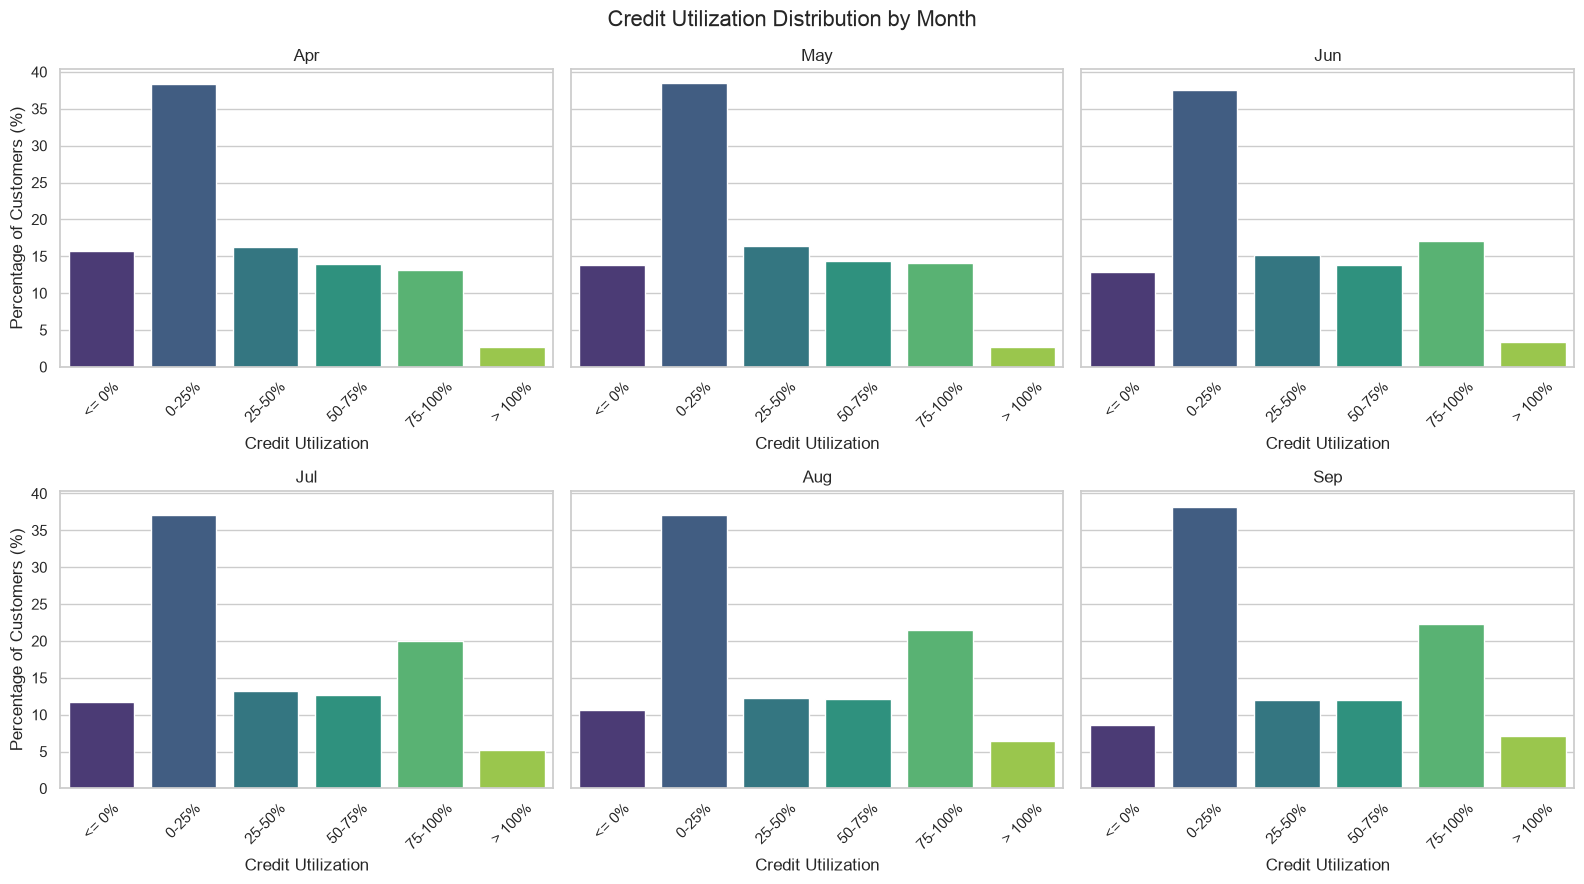

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)

axes = axes.flatten()

for ax, month in zip(axes, MONTH_ORDER):

    # Select observations for the current month
    month_data = util_distribution[
        util_distribution['month'] == month
    ]

    sns.barplot(
        data=month_data,
        x='util_band',
        y='percentage',
        palette='viridis', 
        ax=ax
    )

    ax.set_title(month)
    ax.set_xlabel('Credit Utilization')
    ax.set_ylabel('Percentage of Customers (%)')

    ax.tick_params(
        axis='x',
        rotation=45
    )

fig.suptitle(
    'Credit Utilization Distribution by Month',
    fontsize=16
)

plt.tight_layout()
plt.show()
save(fig, 'Credit_Utilization_by_Month')

**Findings:** Credit utilization varies over the six-month period; however, the 0-25% utilization range consistently remains the most frequent category each month. From April to September, there is a slight shift toward higher utilization levels, with an increasing number of customers using more than 100% of their credit. 

#### Default Rate vs Credit Utilization

In [27]:
#  default rate by month and utilization band
default_by_util = (
    util_long.groupby(['month', 'util_band'], observed=True)[TARGET]
        .agg(default_rate='mean', customer_count='size').reset_index()
)

default_by_util['default_rate'] *= 100
default_by_util

,month,util_band,default_rate,customer_count
0,Apr,<= 0%,23.067120,4708
1,Apr,0-25%,16.331680,11493
2,Apr,25-50%,20.600329,4864
3,Apr,50-75%,26.076555,4180
4,Apr,75-100%,32.777357,3957
5,Apr,> 100%,35.588972,798
6,May,<= 0%,23.912521,4161
7,May,0-25%,16.099931,11528
8,May,25-50%,20.839246,4933
9,May,50-75%,25.428836,4314


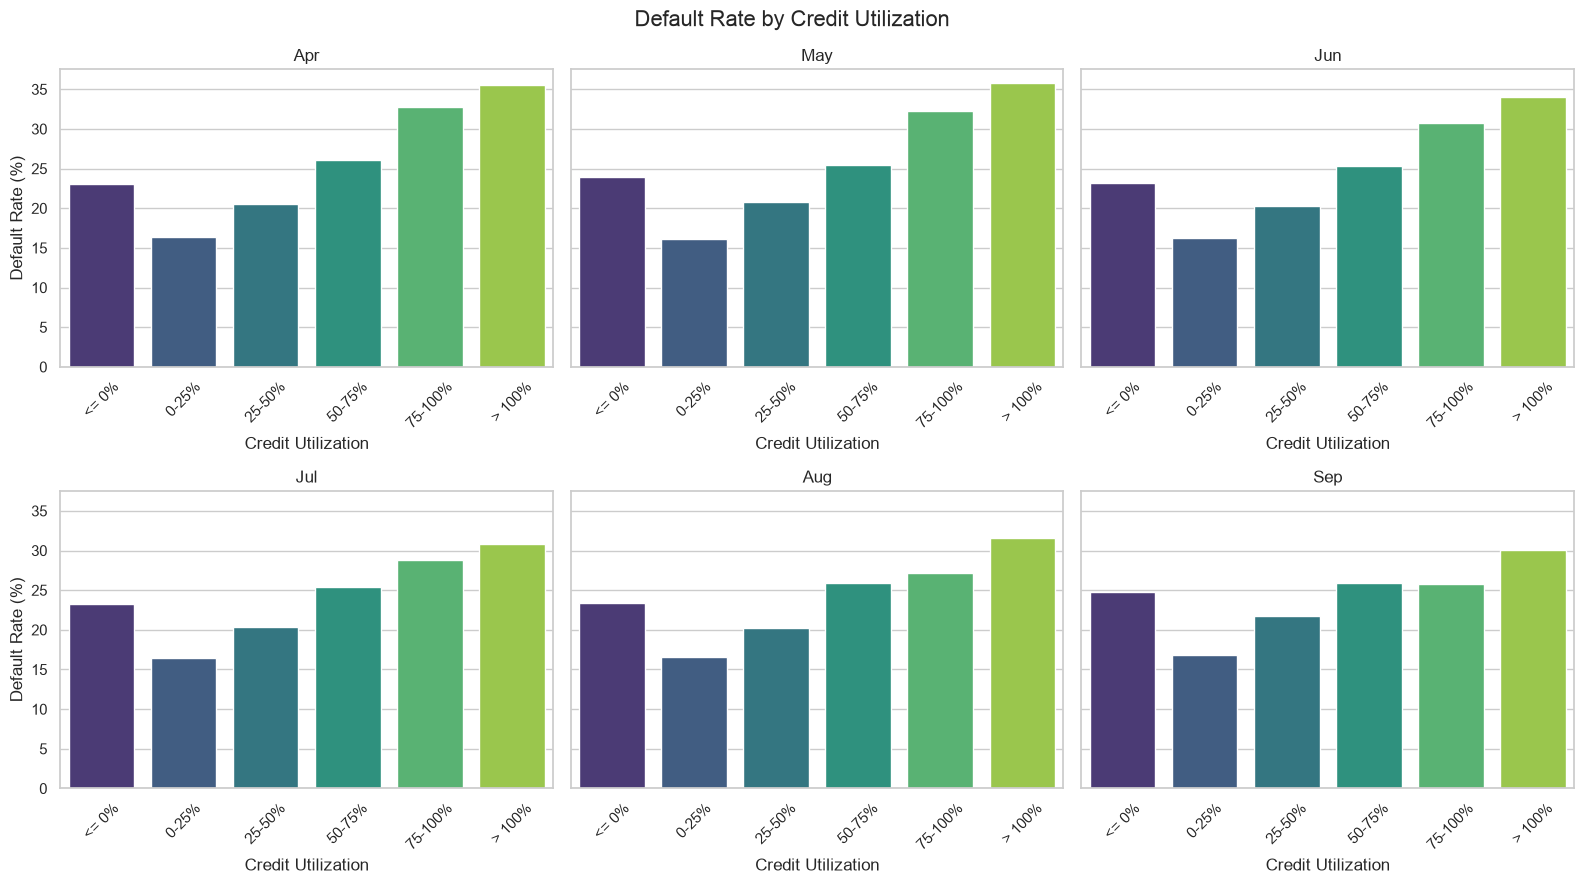

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9), sharey=True)

axes = axes.flatten()

for ax, month in zip(axes, MONTH_ORDER):

    # Select one month
    month_data = default_by_util[
        default_by_util['month'] == month
    ]

    sns.barplot(
        data=month_data,
        x='util_band',
        y='default_rate',
        palette='viridis', 
        ax=ax
    )

    ax.set_title(month)
    ax.set_xlabel('Credit Utilization')
    ax.set_ylabel('Default Rate (%)')

    ax.tick_params(
        axis='x',
        rotation=45
    )

fig.suptitle(
    'Default Rate by Credit Utilization',
    fontsize=16
)

plt.tight_layout()
plt.show()
save(fig, 'Default_Rate_by_Credit_Utilization')

**Findings:** Credit utilization shows a consistent relationship with default over the six-month period. Generally, **higher utilization is associated with increased default risk.** Customers using 0-25% of their credit have the lowest default rates, while those exceeding 100% have some of the highest. However, the group at or below 0% is an exception, as it shows higher default rates than customers using a small percentage of their available credit. Overall, this **trend remains consistent from April to September, suggesting that the engineered utilization features may help distinguish customers with different default-risk levels.**

### Payment amount by default status across the six months


In [29]:
# Map payment amount variables to months
payment_month_map = {
    'PAY_AMT6': 'Apr',
    'PAY_AMT5': 'May',
    'PAY_AMT4': 'Jun',
    'PAY_AMT3': 'Jul',
    'PAY_AMT2': 'Aug',
    'PAY_AMT1': 'Sep'
}

# Convert payment amounts from wide to long format
payment_long = df_eda.melt(
    id_vars=TARGET,
    value_vars=PAYAMT_COLS,
    var_name='payment_month',
    value_name='payment_amount'
)

# Replace variable names with month names
payment_long['month'] = (
    payment_long['payment_month']
    .map(payment_month_map)
)

# Put months in chronological order
payment_long['month'] = pd.Categorical(
    payment_long['month'],
    categories=['Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep'],
    ordered=True
)

payment_long.head()

,DEFAULT,payment_month,payment_amount,month
0,1,PAY_AMT1,0,Sep
1,1,PAY_AMT1,0,Sep
2,0,PAY_AMT1,1518,Sep
3,0,PAY_AMT1,2000,Sep
4,0,PAY_AMT1,2000,Sep


In [30]:
# Calculate median payment amount for each default group
payment_default = (
    payment_long
    .groupby(
        ['month', TARGET],
        observed=True
    )['payment_amount']
    .median()
    .reset_index()
)
payment_default['default_label'] = (
    payment_default[TARGET]
    .map({
        0: 'No Default',
        1: 'Default'
    })
)
payment_default

,month,DEFAULT,payment_amount,default_label
0,Apr,0,1706.0,No Default
1,Apr,1,1000.0,Default
2,May,0,1765.0,No Default
3,May,1,1000.0,Default
4,Jun,0,1734.0,No Default
5,Jun,1,1000.0,Default
6,Jul,0,2000.0,No Default
7,Jul,1,1222.0,Default
8,Aug,0,2247.5,No Default
9,Aug,1,1533.5,Default


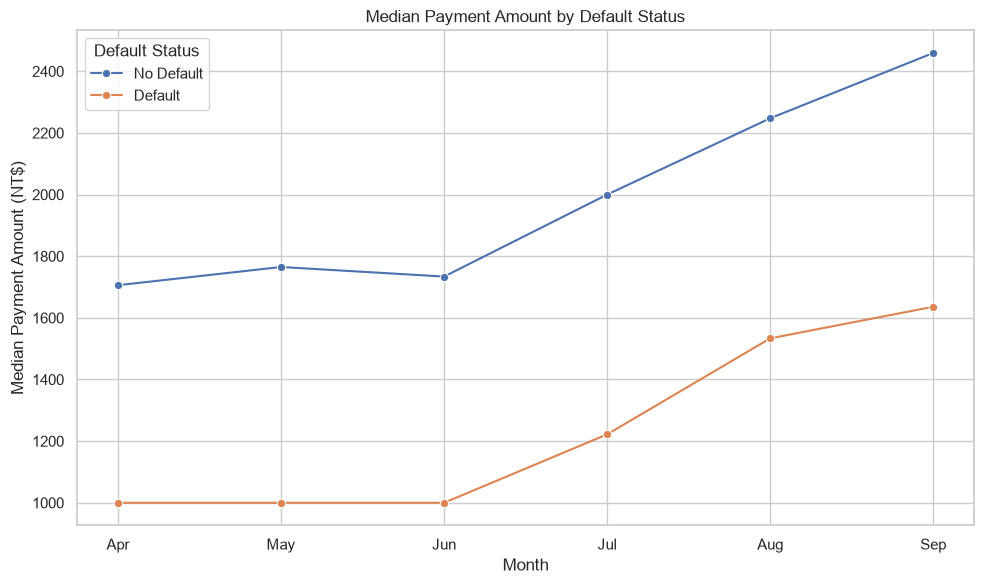

In [31]:
fig = plt.figure(figsize=(10, 6))

sns.lineplot(
    data=payment_default,
    x='month',
    y='payment_amount',
    hue='default_label',
    marker='o'
)

plt.title('Median Payment Amount by Default Status')
plt.xlabel('Month')
plt.ylabel('Median Payment Amount (NT$)')

plt.legend(title='Default Status')

plt.tight_layout()
plt.show()
save(fig, 'Median_Payment_Amount_by_Default_Status')

**Findings:** Median payment amounts consistently differ between customers who default and those who do not. Across all six months, customers who eventually default make lower median payments than non-defaulting customers. Median payments increase over time for both groups; however, the payment gap remains consistently significant, suggesting that lower payment amounts are associated with subsequent default and that historical payment behavior may help distinguish customers with different default outcomes.

### Median bill amount by default status

In [32]:
# map bill amount variables to months
bill_month_map = {
    'BILL_AMT6': 'Apr',
    'BILL_AMT5': 'May',
    'BILL_AMT4': 'Jun',
    'BILL_AMT3': 'Jul',
    'BILL_AMT2': 'Aug',
    'BILL_AMT1': 'Sep'
}

# bill amounts from wide to long format
bill_long = df_eda.melt(
    id_vars=TARGET,
    value_vars=BILL_COLS,
    var_name='bill_month',
    value_name='bill_amount'
)

# replace variable names with month names
bill_long['month'] = (
    bill_long['bill_month']
    .map(bill_month_map)
)

# Put months in chronological order
bill_long['month'] = pd.Categorical(
    bill_long['month'],
    categories=['Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep'],
    ordered=True
)

bill_long.head()

,DEFAULT,bill_month,bill_amount,month
0,1,BILL_AMT1,3913,Sep
1,1,BILL_AMT1,2682,Sep
2,0,BILL_AMT1,29239,Sep
3,0,BILL_AMT1,46990,Sep
4,0,BILL_AMT1,8617,Sep


In [33]:
# Calculate median bill amount by month and default status
bill_default = (
    bill_long
    .groupby(
        ['month', TARGET],
        observed=True
    )['bill_amount']
    .median()
    .reset_index()
)

bill_default['default_label'] = (
    bill_default[TARGET]
    .map({
        0: 'No Default',
        1: 'Default'
    })
)

bill_default

,month,DEFAULT,bill_amount,default_label
0,Apr,0,16679.0,No Default
1,Apr,1,18028.5,Default
2,May,0,17998.0,No Default
3,May,1,18478.5,Default
4,Jun,0,19000.0,No Default
5,Jun,1,19119.5,Default
6,Jul,0,20202.5,No Default
7,Jul,1,19834.5,Default
8,Aug,0,21660.5,No Default
9,Aug,1,20300.5,Default


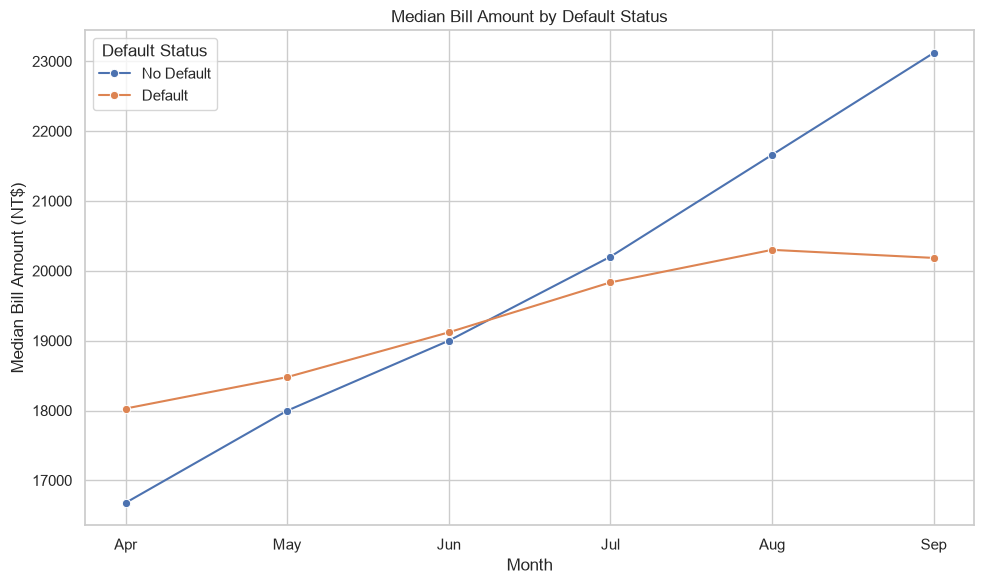

In [34]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=bill_default,
    x='month',
    y='bill_amount',
    hue='default_label',
    marker='o'
)

plt.title('Median Bill Amount by Default Status')
plt.xlabel('Month')
plt.ylabel('Median Bill Amount (NT$)')

plt.legend(title='Default Status')

plt.tight_layout()
plt.show()

**Findings:** Median bill amounts do not show the same consistent separation between defaulting and non-defaulting customers observed for payment amounts. In the earlier months, customers who eventually default have slightly higher median bill balances, which then decline in subsequent months. 

### Candidate Engineered Credit Utilization Features

In [35]:
# Average utilization over six months
df_eda['UTIL_AVG'] = df_eda[util_cols].mean(axis=1)

# Maximum utilization during the six-month period
df_eda['UTIL_MAX'] = df_eda[util_cols].max(axis=1)

# Most recent utilization
df_eda['UTIL_RECENT'] = df_eda['UTIL_1']

# Change from April to September
df_eda['UTIL_CHANGE'] = (
    df_eda['UTIL_1'] - df_eda['UTIL_6']
)

# util features
util_features = [
    'UTIL_AVG',
    'UTIL_MAX',
    'UTIL_RECENT',
    'UTIL_CHANGE'
]

df_eda[util_features].describe().T

,count,mean,std,min,25%,50%,75%,max
UTIL_AVG,30000.0,0.373048,0.351890,-0.232590,0.029997,0.284834,0.687929,5.364308
UTIL_MAX,30000.0,0.494965,0.433046,-0.100000,0.070636,0.430702,0.923246,10.688575
UTIL_RECENT,30000.0,0.423771,0.411462,-0.619892,0.022032,0.313994,0.829843,6.455300
UTIL_CHANGE,30000.0,0.105187,0.301370,-1.827300,-0.029097,0.006860,0.181202,5.309500


### Default rate by credit limit

In [36]:
# Inspect the distribution of credit limits
df_eda['LIMIT_BAL'].describe()

count      30000.000000
mean      167484.322667
std       129747.661567
min        10000.000000
25%        50000.000000
50%       140000.000000
75%       240000.000000
max      1000000.000000
Name: LIMIT_BAL, dtype: float64

In [37]:
# Define credit limit bands
limit_bins = [
    0,
    50000,
    100000,
    200000,
    300000,
    500000,
    float('inf')
]

limit_labels = [
    '<= 50K',
    '50K-100K',
    '100K-200K',
    '200K-300K',
    '300K-500K',
    '> 500K'
]

# Assign customers to credit limit bands
df_eda['LIMIT_BAND'] = pd.cut(
    df_eda['LIMIT_BAL'],
    bins=limit_bins,
    labels=limit_labels,
    include_lowest=True
)

In [38]:
# Calculate default rate within each credit limit band
default_by_limit = (
    df_eda
    .groupby(
        'LIMIT_BAND',
        observed=True
    )[TARGET]
    .agg(
        default_rate='mean',
        customer_count='size'
    )
    .reset_index()
)

# Convert default rate to percentage
default_by_limit['default_rate'] *= 100

default_by_limit

,LIMIT_BAND,default_rate,customer_count
0,<= 50K,31.787389,7676
1,50K-100K,25.798424,4822
2,100K-200K,19.479695,7880
3,200K-300K,16.050603,5059
4,300K-500K,13.357815,4357
5,> 500K,11.165049,206


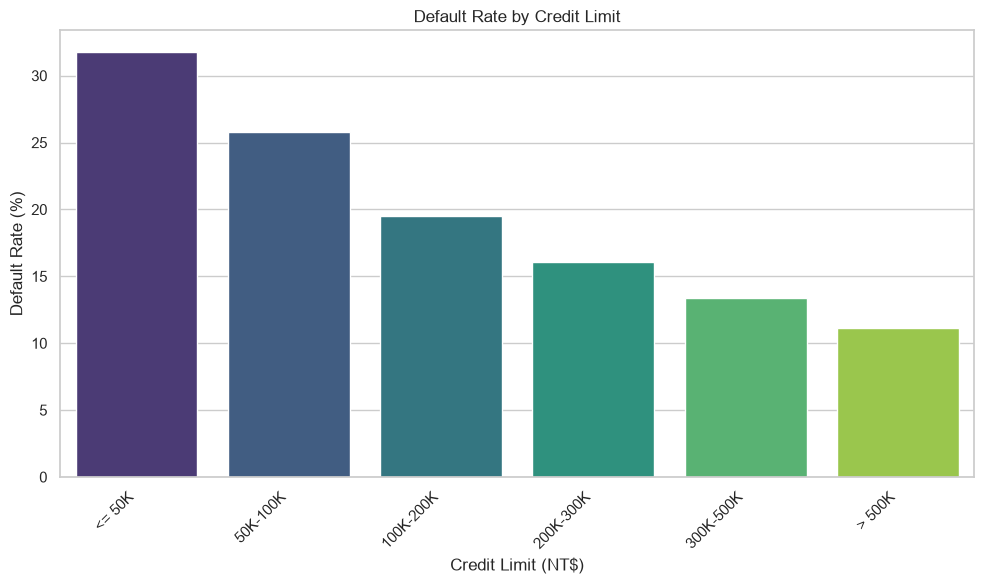

In [39]:
fig = plt.figure(figsize=(10, 6))

sns.barplot(
    data=default_by_limit,
    x='LIMIT_BAND',
    palette='viridis', 
    y='default_rate'
)

plt.title('Default Rate by Credit Limit')
plt.xlabel('Credit Limit (NT$)')
plt.ylabel('Default Rate (%)')

plt.xticks(
    rotation=45,
    ha='right'
)

plt.tight_layout()
plt.show()
save(fig, 'Default_Rate_by_Credit_Limit')

**Findings:** Default rates consistently decline as credit limits increase. Customers with credit limits of $\$50,000$ or less have the highest default rate at around 35%, while those with limits between $\$50,000$ and $\$100,000$ have a default rate of around 25%. 
As credit limits increase, default rates continue to decline, indicating a strong negative correlation between credit limit size and default risk in the data. However, this relationship does not necessarily imply that larger credit limits lead to lower default rates, as other factors may also be involved.


In [40]:
# column to move to the end
col_to_move = 'DEFAULT'

# list of all other columns
other_cols = [col for col in df_eda.columns if col != col_to_move]

# reorder, put column at the end
df_eda = df_eda[other_cols + [col_to_move]]

In [41]:
df_eda.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,UTIL_3,UTIL_4,UTIL_5,UTIL_6,UTIL_AVG,UTIL_MAX,UTIL_RECENT,UTIL_CHANGE,LIMIT_BAND,DEFAULT
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0.034450,0.000000,0.000000,0.000000,0.064200,0.195650,0.195650,0.195650,<= 50K,1
1,120000,2,2,2,26,-1,2,0,0,0,...,0.022350,0.027267,0.028792,0.027175,0.023718,0.028792,0.022350,-0.004825,100K-200K,1
2,90000,2,2,2,34,0,0,0,0,0,...,0.150656,0.159233,0.166089,0.172767,0.188246,0.324878,0.324878,0.152111,50K-100K,0
3,50000,2,2,1,37,0,0,0,0,0,...,0.985820,0.566280,0.579180,0.590940,0.771113,0.985820,0.939800,0.348860,<= 50K,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,0.716700,0.418800,0.382920,0.382620,0.364463,0.716700,0.172340,-0.210280,<= 50K,0


### Correlation

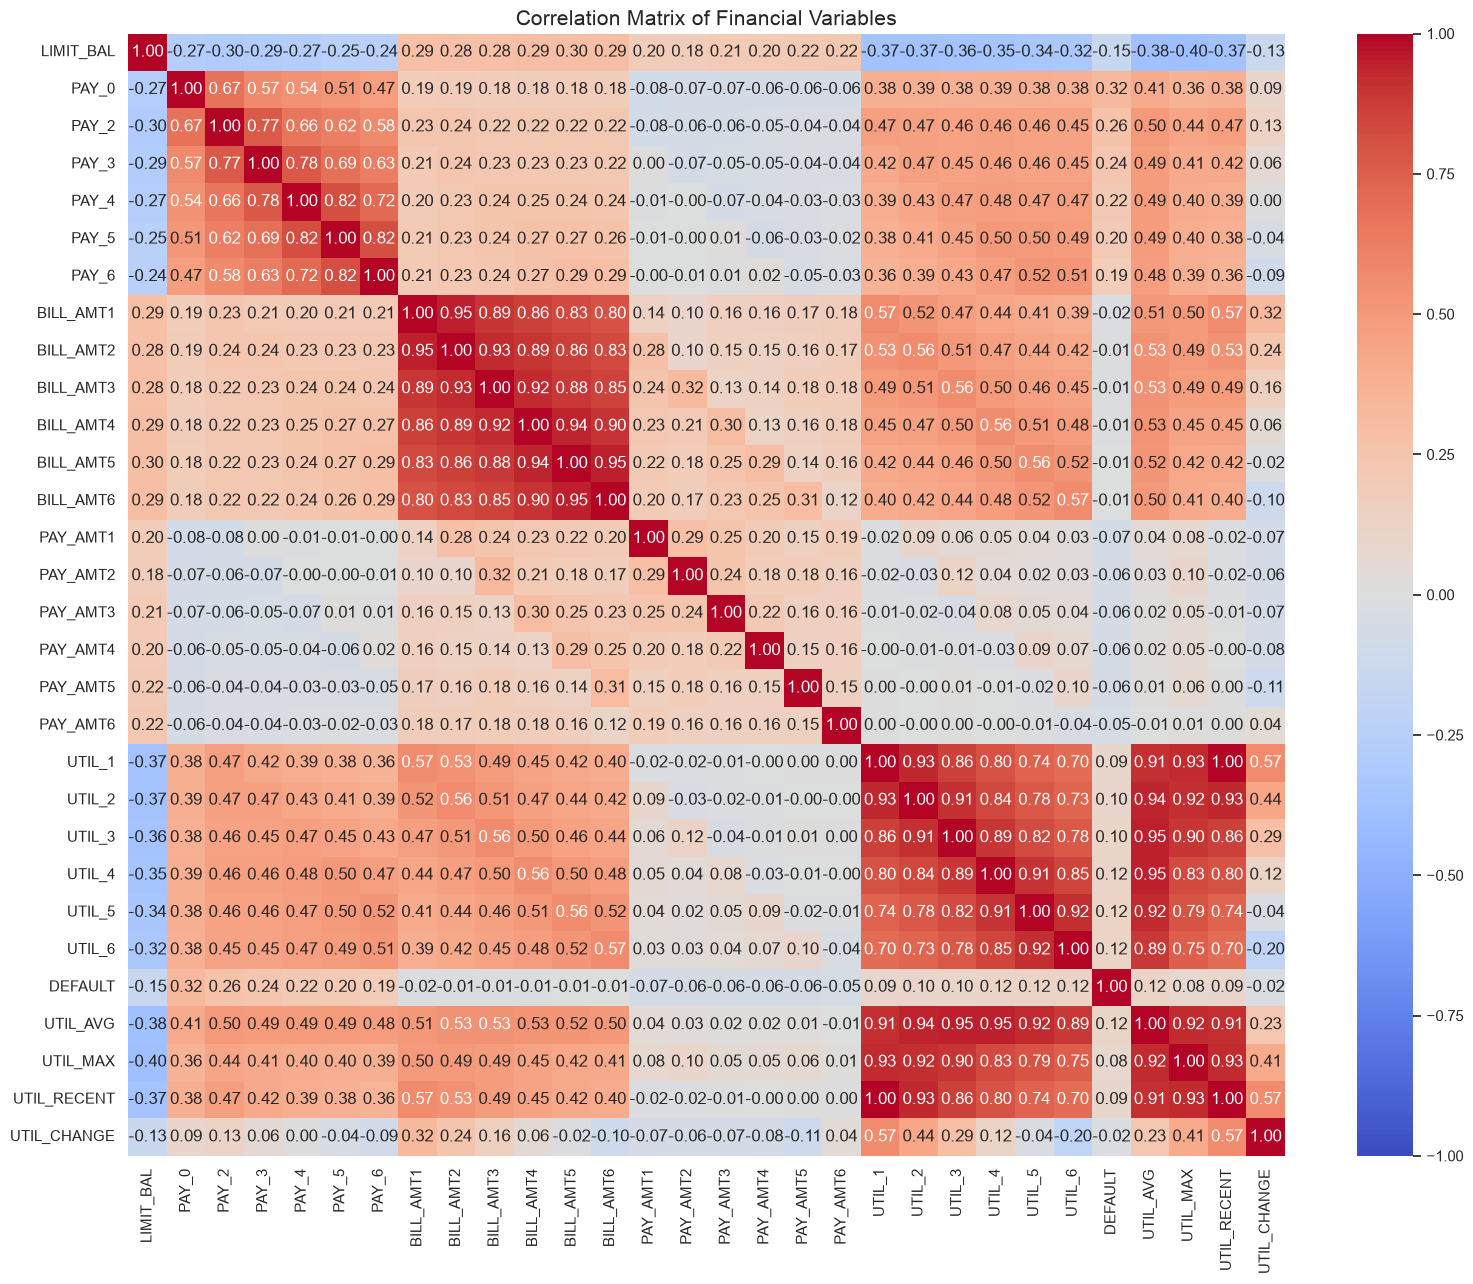

In [42]:
# Select financial variables for correlation analysis
corr_cols = (
    ['LIMIT_BAL']
    + PAY_COLS
    + BILL_COLS
    + PAYAMT_COLS
    + util_cols
    + [TARGET]
    + util_features
)

# Calculate the correlation matrix
corr_matrix = df_eda[corr_cols].corr()

# Create the heatmap
fig = plt.figure(figsize=(16, 13))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    annot=True, 
    fmt=".2f",
    center=0,
    vmin=-1,
    vmax=1
)



plt.title('Correlation Matrix of Financial Variables', fontsize=15)

plt.tight_layout()
plt.show()
save(fig, 'Correlation_Matrix')

**Findings:** The correlation matrix reveals significant relationships among the monthly financial variables. Bill amounts are strongly positively correlated across months, with correlations generally ranging from approximately 0.80 to 0.95, indicating that customers with higher balances in one month tend to maintain higher balances in subsequent months. Monthly repayment-status variables are also moderately to strongly correlated. Similarly, the engineered utilization variables show strong correlations across months, suggesting consistent customer habits.

With respect to `DEFAULT`, repayment status shows the strongest correlations among the variables examined:   
`PAY_0`: 0.32  
`PAY_2`: 0.26  
`PAY_3`: 0.24  
`PAY_4`: 0.22   
`PAY_5`: 0.20   
`PAY_6`: 0.19  

Credit utilization `UTIL_` features also show modest positive correlations with `DEFAULT`, while raw bill amounts show almost no linear correlation, suggesting that these engineered features may provide useful discriminant information.

In [43]:
df_eda.to_csv('../data/credit_default_engineered.csv', index=False)

## EDA Summary

The exploratory data analysis identified several patterns that may help predict customer default. 

- The target variable is moderately imbalanced, with approximately 22% of customers defaulting and 78% not defaulting. Model evaluation should consider metrics beyond overall classification accuracy
- Demographic characteristics show some differences in observed default rates. Default rates differ by sex, education, marital status, and age group; however, these differences are not as significant as those seen in repayment and credit behavior. Demographic characteristics may provide supplementary predictive information rather than serving as the primary indicators of default risk.
- Repayment history appears to contain some of the strongest signals of default. Customers with longer payment delays generally have higher observed default rates, and the association with default is stronger for more recent repayment-status variables, suggesting that both the severity and recency of delinquency may meaningfully predict default.
- Credit limit and credit utilization provide additional evidence of differences in default behavior. Customers with lower credit limits have higher observed default rates, and default rates generally increase as credit utilization rises.
- Engineered utilization features also suggest that high credit utilization may be particularly informative.

Overall, the EDA suggests that default risk is more strongly associated with repayment behavior, credit utilization, credit limit, and payment behavior than with demographic characteristics alone. 



### Other Visualizations

In [44]:
# function to create multiple crosstabs
def create_crosstab(df, col, target, title=None):
    '''
    This function creates normalized and raw count crosstabs 
    and plots multiple features against target
    '''
    #create crosstab
    crosstab = pd.crosstab(df[col], df[target])
    #normalize 
    crosstab_norm = crosstab.div(crosstab.sum(axis=1), axis =0)
    #create plots
    fig, axes =plt.subplots(1,2, figsize =(10,6))

    colors = sns.color_palette("GnBu_r", 2)

    #raw counts
    crosstab.plot(
        kind='bar',
        stacked=True,
        color=colors,
        # legend=False,
        ax=axes[0]
        
    )
    # normalized
    crosstab_norm.plot(
        kind='bar',
        stacked=True,
        color=colors,
        ax=axes[1]
    )

    # title
    if title is None:
        title = f'{target} by {col}'
    
    axes[0].set_title(title)
    axes[1].set_title(f'{title} Normalized')
    axes[0].set_ylabel('Count')
    axes[1].set_ylabel('Proportion')
    axes[0].legend(loc='lower right')
    axes[1].legend(loc='lower right')
    # plt.legend(loc = 'best')


    plt.tight_layout()
    plt.show()

    return crosstab, crosstab_norm

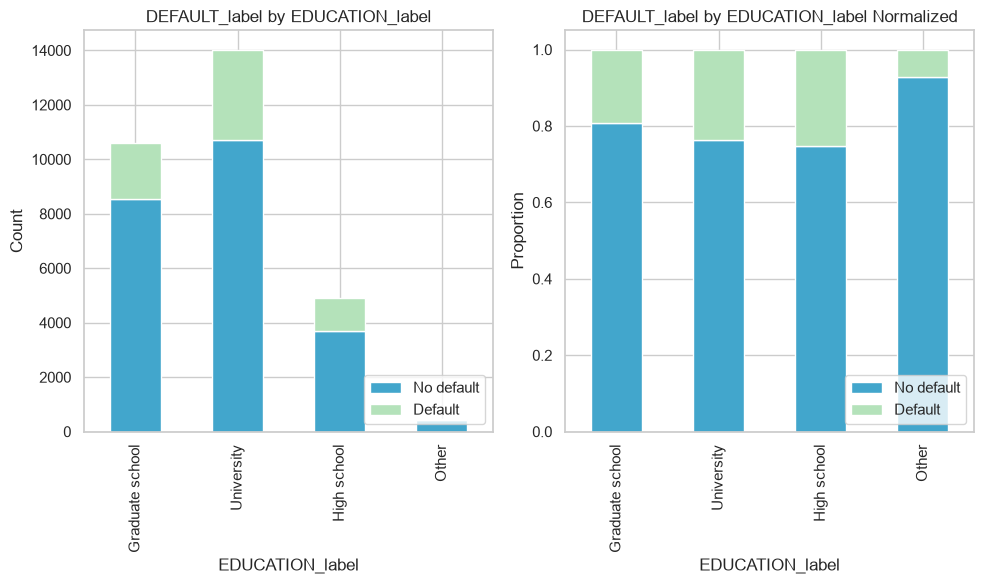

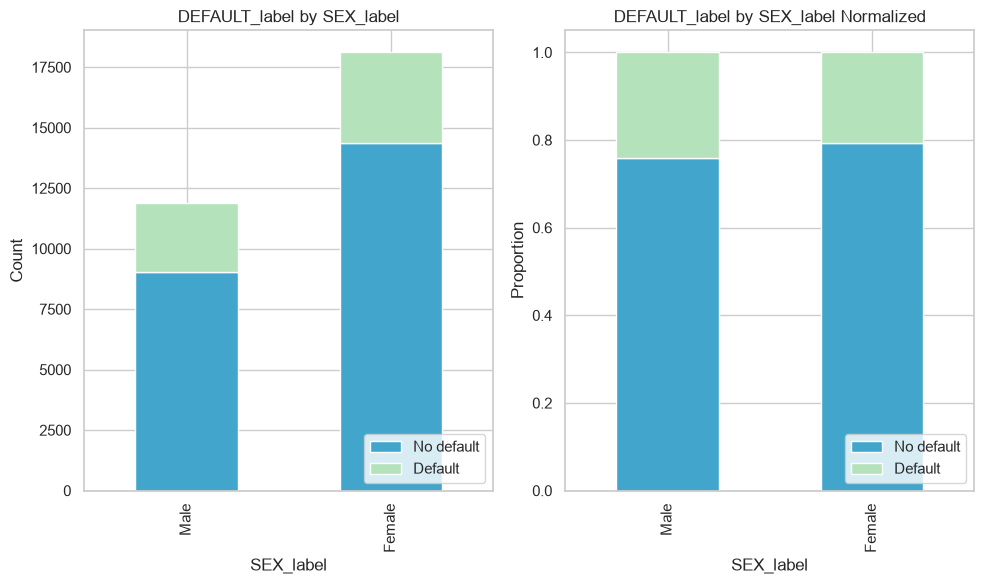

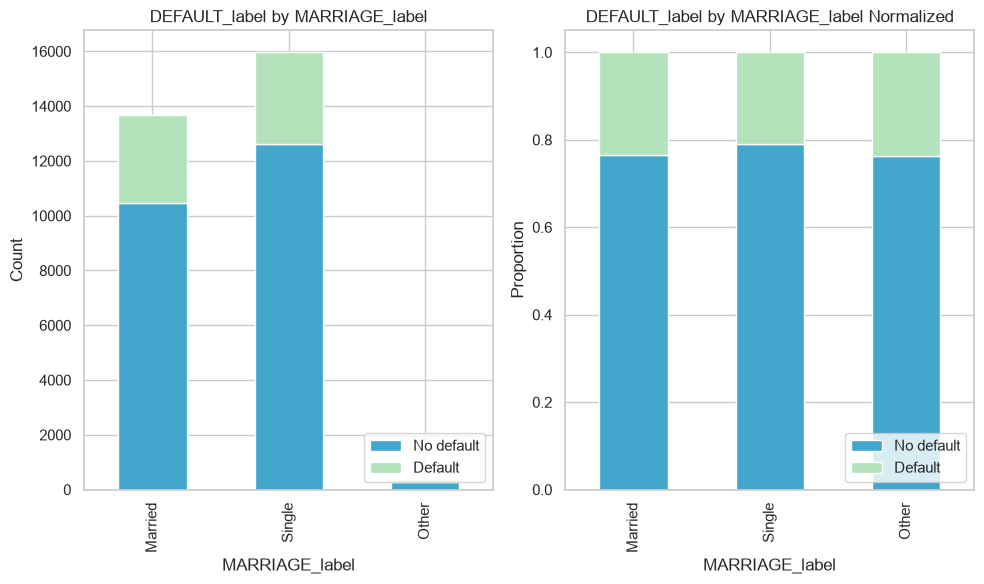

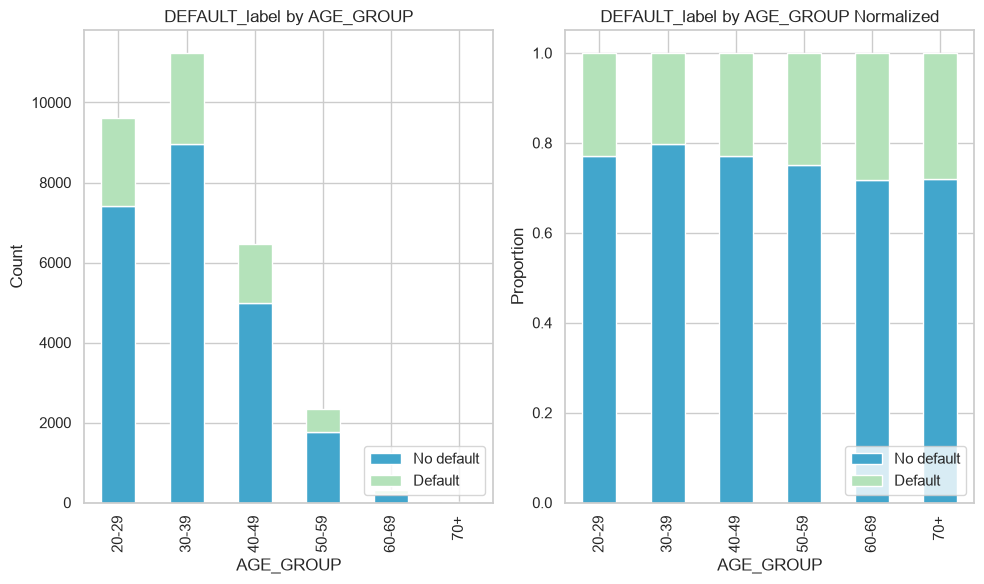

In [45]:
def create_multiple_crosstabs(df, pairs):
    results = {}
    
    for row_col, col_col in pairs:
        results[(row_col, col_col)] = create_crosstab(
            df,
            row_col,
            col_col
        )
    
    return results

pairs = [
    ('EDUCATION_label', 'DEFAULT_label'),
    ('SEX_label', 'DEFAULT_label'),
    ('MARRIAGE_label', 'DEFAULT_label'),
    ('AGE_GROUP','DEFAULT_label'),
]      
results = create_multiple_crosstabs(df_eda, pairs)